# Layer 7: multi-scale structure, hierarchical moons

The flow notebooks form a difficulty series along different axes:

| notebook | target | what makes it hard |
|---|---|---|
| [05](05_flow_matching.ipynb) | two moons in $\mathbb R^2$ | nothing: saturates by $w\approx64$ |
| [06](06_flow_matching_hard.ipynb) | 4 moon-pairs entangled in $\mathbb R^8$ | dimension + entanglement |
| **07** (this one) | the same, but every plane is **two-scale** | + structure ${\sim}15\times$ smaller than the arcs |

**The target.** Each plane is a sharp two-moons *convolved with a miniature two-moons*:

$$m = m_\text{coarse} + 0.18\, m_\text{fine},\qquad
m_\text{coarse}\sim\text{moons}(\sigma{=}0.02),\quad m_\text{fine}\sim\text{moons}(\sigma{=}0.05),$$

so every arc becomes a moon-shaped **ribbon** whose cross-section carries fine structure at
scale $\approx0.27$. Four such planes are stacked and mixed by the fixed rotation as in
notebook 06. The velocity field must now model the coarse geometry, the fine ribbon
structure, and the entanglement at once; resolving features this small pushes both the
capacity term $A/N^\alpha$ and the data term $B/D^\beta$ far beyond notebook 06, so the grid
extends to $w=768$ and $D=2^{23}$.

dim=8; two-scale planes: coarse moons + 0.18 x fine moons
LR law: eta*(w,T) = 0.01553 (w/64)^-0.644 (T/2048)^-0.512


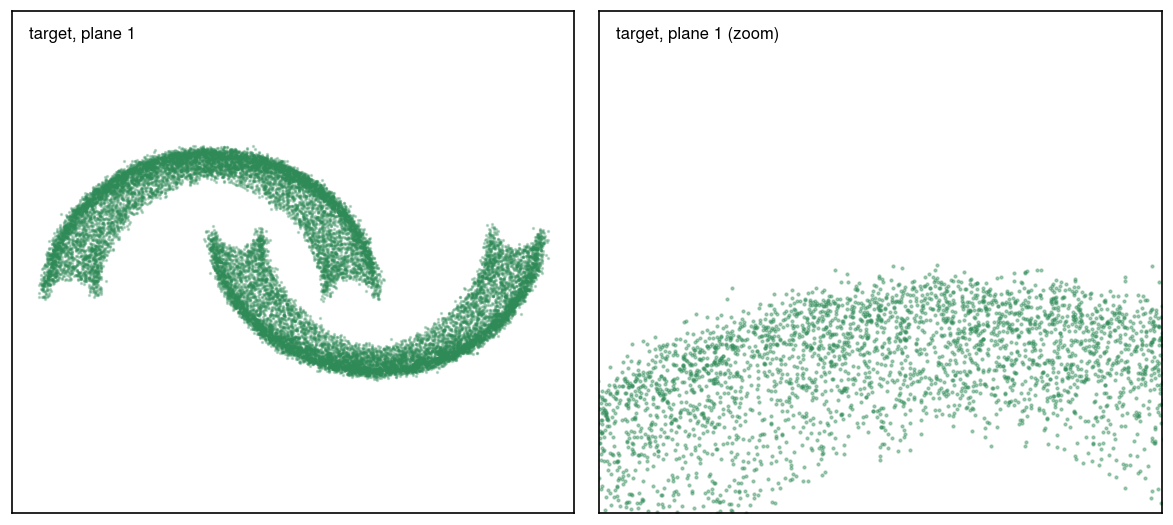

In [1]:
import json
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

from scaling_laws.flow import HierarchicalMoonsFlow
from scaling_laws.live import train_cell_live
from scaling_laws.sweep import aggregate, transfer_lr
from scaling_laws import approaches as ap, plotting as pl
pl.set_style()

RESULTS = Path("../results").resolve(); FIGDIR = RESULTS / "figures"
ZOOM = dict(xlim=(-1.8, -0.4), ylim=(0.8, 2.0))          # the upper-left arc, magnified
prob = HierarchicalMoonsFlow(n_pairs=4)
law = json.load(open(RESULTS / "flowh_hp_study_cosine.json"))
lr_of = transfer_lr(eta_ref=law["eta_ref"], w_ref=law["w_ref"], T_ref=law["T_ref"],
                    c_w=law["c_w"], c_T=law["c_T"], lr_max=0.1)
print(f"dim={prob.dim}; two-scale planes: coarse moons + {prob.sub_scale} x fine moons")
print(f"LR law: eta*(w,T) = {law['eta_ref']} (w/{law['w_ref']})^{law['c_w']} (T/{law['T_ref']})^{law['c_T']}")

xt = prob.unrotate(prob.sample_target(20000, torch.Generator().manual_seed(0)))
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
axes[0].scatter(xt[:, 0], xt[:, 1], s=1, alpha=.3, color="seagreen")
axes[0].set(xlim=(-3, 3), ylim=(-3, 3))
axes[1].scatter(xt[:, 0], xt[:, 1], s=2.5, alpha=.4, color="seagreen")
axes[1].set(**ZOOM)
for a, l in zip(axes, ["target, plane 1", "target, plane 1 (zoom)"]):
    a.set(xticks=[], yticks=[]); a.text(.03, .97, l, transform=a.transAxes, va="top", fontsize=10)
fig.tight_layout(); plt.show()

## The generation ladder, with a magnifying glass

Top row: plane 1 of the generated samples across a ladder of $(w, D)$ cells. Bottom row: the
same samples zoomed onto one arc. Small models miss even the coarse moons; mid-sized models
draw clean arcs whose zoom is a diffuse blob; only the largest cell starts to reproduce the
ribbon profile. The coarse and fine structure resolve at *different points of the scaling
curve*, which is exactly what multi-scale targets are expected to do.

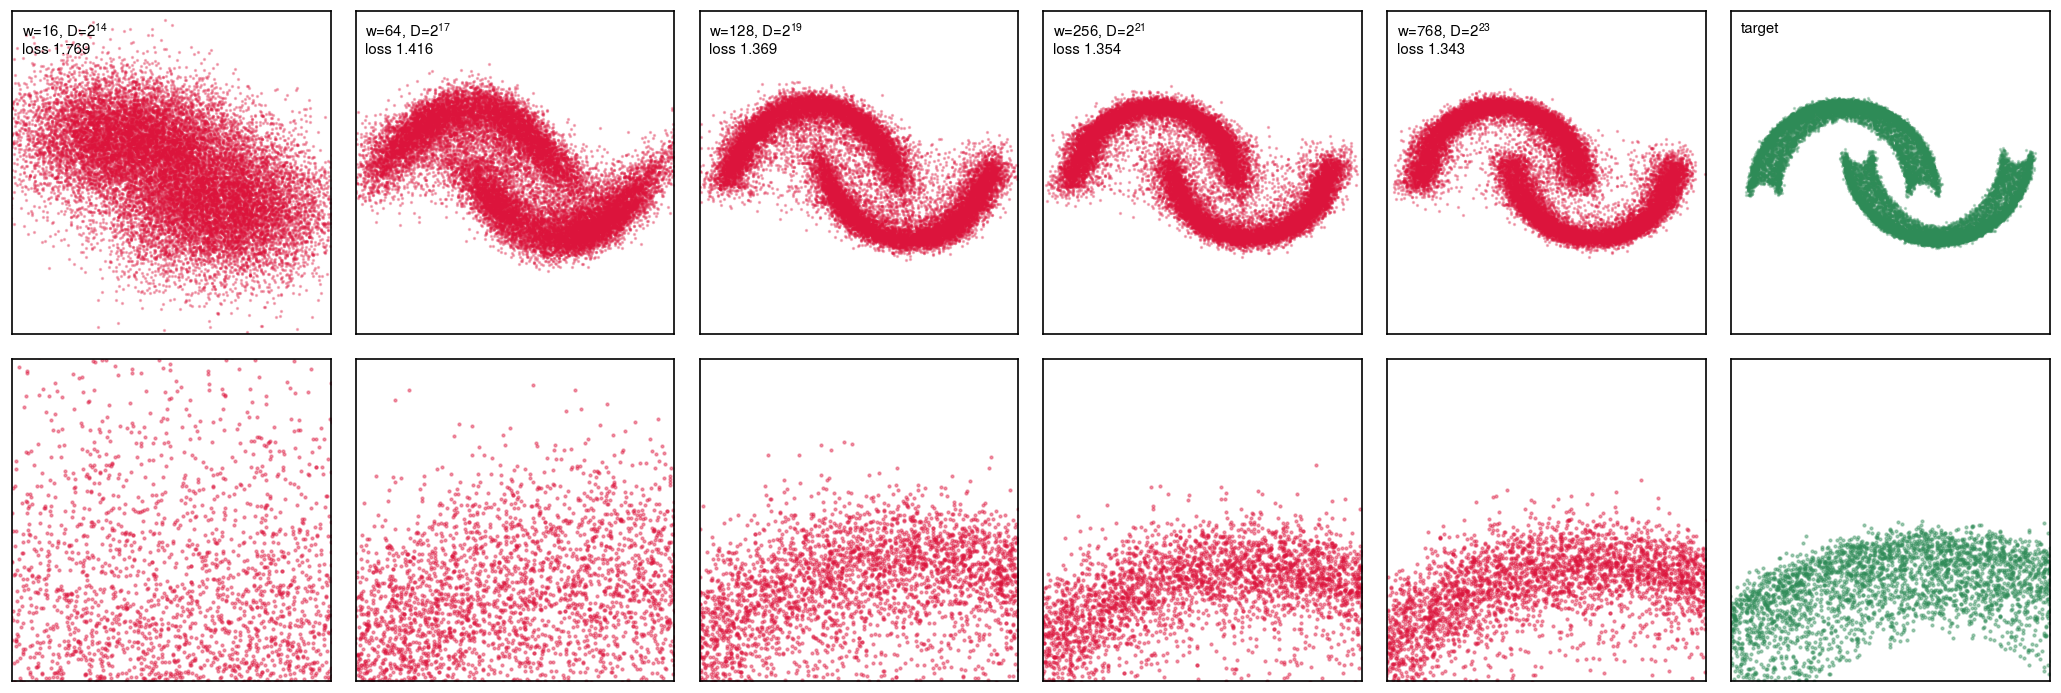

In [2]:
ladder = [(16, 2**14), (64, 2**17), (128, 2**19), (256, 2**21), (768, 2**23)]
fig, axes = plt.subplots(2, len(ladder) + 1, figsize=(2.9 * (len(ladder) + 1), 6.0))
for col, (w, D) in enumerate(ladder):
    lv, _, _, m = train_cell_live(prob, w, D, lr_of(w, prob.n_steps(D, 256)),
                                  plot=False, progress=False, return_model=True)
    xs = prob.unrotate(prob.sample(m, 20000, seed=2))
    axes[0, col].scatter(xs[:, 0], xs[:, 1], s=1, alpha=.3, color="crimson")
    axes[1, col].scatter(xs[:, 0], xs[:, 1], s=2.5, alpha=.4, color="crimson")
    axes[0, col].text(.03, .97, f"w={w}, D=$2^{{{int(np.log2(D))}}}$\nloss {lv:.3f}",
                      transform=axes[0, col].transAxes, va="top", fontsize=9)
axes[0, -1].scatter(xt[:, 0], xt[:, 1], s=1, alpha=.3, color="seagreen")
axes[1, -1].scatter(xt[:, 0], xt[:, 1], s=2.5, alpha=.4, color="seagreen")
axes[0, -1].text(.03, .97, "target", transform=axes[0, -1].transAxes, va="top", fontsize=9)
for a in axes[0]:
    a.set(xlim=(-3, 3), ylim=(-3, 3), xticks=[], yticks=[])
for a in axes[1]:
    a.set(**ZOOM); a.set(xticks=[], yticks=[])
fig.tight_layout()
pl.save_figure(fig, "flowh_generation_ladder", outdir=FIGDIR); plt.show()

## The grid, three ways

[`run_flow_sweep.py --hier`](../scripts/run_flow_sweep.py): widths 16 to 768, $D$ to $2^{23}$,
per-cell LR from a law re-calibrated on an extended range (widths to 384, horizons to
$T{=}16384$) so the biggest cells are not extrapolating far.

grid: 8 model sizes x 14 data budgets, N from 568 to 604,424 params


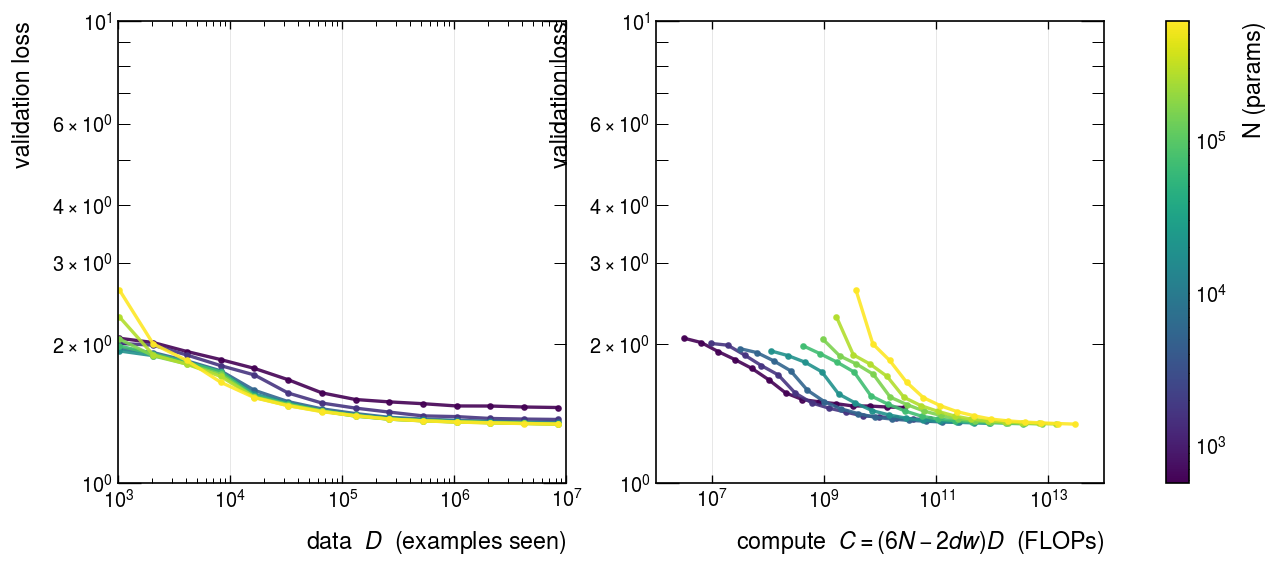

In [3]:
agg = aggregate(pd.read_csv(RESULTS / "flowh_sweep_cosine.csv"))
print(f"grid: {agg['N'].nunique()} model sizes x {agg['D'].nunique()} data budgets, "
      f"N from {agg['N'].min():,} to {agg['N'].max():,} params")
fig = pl.plot_all_runs(agg)
pl.save_figure(fig, "flowh_overview", outdir=FIGDIR); plt.show()

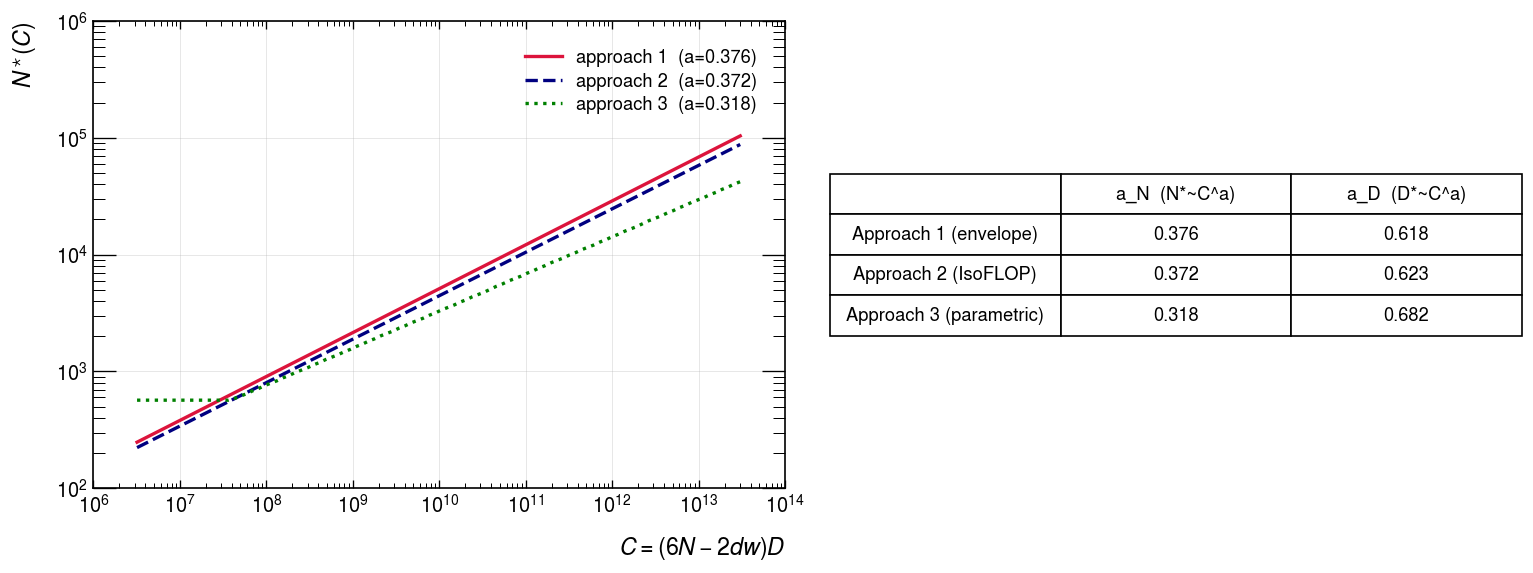

fitted floor (Approach 3):  E = 1.3220
exponents: alpha = 0.976, beta = 0.455, a_N = 0.318


In [4]:
env = ap.training_curve_envelope(agg)
iso = ap.isoflop_profiles(agg, n_targets=8)
par = ap.parametric_fit(agg)
fig = pl.plot_comparison(env, iso, par, (agg["C"].min(), agg["C"].max()))
pl.save_figure(fig, "flowh_comparison", outdir=FIGDIR); plt.show()
print(f"fitted floor (Approach 3):  E = {par.E:.4f}")
print(f"exponents: alpha = {par.alpha:.3f}, beta = {par.beta:.3f}, a_N = {par.a_N:.3f}")

## Floor and excess

Same protocol as notebooks 05 and 06: a large reference model bounds the floor from above,
importance sampling (restricted to $t\le0.9$, with its 8D effective-sample-size caveat)
cross-checks it, and Approach 3 fits it from the grid.

In [5]:
D_ref = 2**23
val_ref, _, _, ref = train_cell_live(prob, 1024, D_ref, lr_of(1024, prob.n_steps(D_ref, 256)),
                                     plot=False, progress=True, return_model=True)
E_is, ess = prob.estimate_floor(n_points=2048, t_max=0.9)
mask = prob.x_val[:, -1] <= 0.9
sub = torch.nn.functional.mse_loss(ref(prob.x_val[mask]), prob.v_val[mask]).item()
print(f"reference model (w=1024, D=2^23): loss = {val_ref:.4f}   <- empirical floor")
print(f"Approach 3 fitted floor:         E    = {par.E:.4f}")
print(f"IS floor, t<=0.9:                E    = {E_is:.4f}  (mean ESS {ess:.0f})")
print(f"reference model on t<=0.9:              {sub:.4f}  (apples-to-apples check)")

w=1024, D=8,388,608:   0%|          | 0/32768 [00:00<?, ?step/s]

w=1024, D=8,388,608:   0%|          | 20/32768 [00:00<02:49, 193.59step/s]

w=1024, D=8,388,608:   0%|          | 41/32768 [00:00<02:41, 202.33step/s]

w=1024, D=8,388,608:   0%|          | 62/32768 [00:00<02:44, 198.76step/s]

w=1024, D=8,388,608:   0%|          | 82/32768 [00:00<02:46, 196.05step/s]

...

w=1024, D=8,388,608: 100%|█████████▉| 32710/32768 [02:46<00:00, 194.65step/s]

w=1024, D=8,388,608: 100%|█████████▉| 32730/32768 [02:46<00:00, 193.87step/s]

w=1024, D=8,388,608: 100%|█████████▉| 32750/32768 [02:46<00:00, 194.09step/s]

w=1024, D=8,388,608: 100%|█████████▉| 32767/32768 [02:46<00:00, 196.96step/s]

reference model (w=1024, D=2^23): loss = 1.3436   <- empirical floor
Approach 3 fitted floor:         E    = 1.3220
IS floor, t<=0.9:                E    = 1.3708  (mean ESS 36041)
reference model on t<=0.9:              1.3779  (apples-to-apples check)


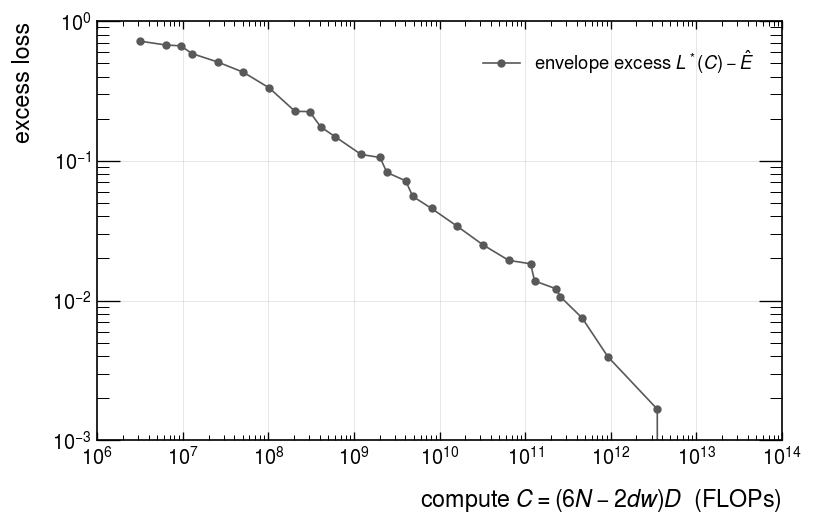

In [6]:
fr = env.frontier.sort_values("C")
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.plot(fr["C"], fr["val_loss"] - val_ref, "o-", color="0.35", ms=4, lw=1,
        label=r"envelope excess $L^*(C)-\hat E$")
ax.set(xscale="log", yscale="log", xlabel=r"compute $C=(6N-2dw)D$  (FLOPs)",
       ylabel="excess loss")
ax.legend(frameon=False)
fig.tight_layout()
pl.save_figure(fig, "flowh_excess", outdir=FIGDIR); plt.show()

## Takeaways

- **Structure, not just dimension, sets the difficulty.** Notebooks 05, 06 and 07 share the
  recipe and (for 06 and 07) even the dimension; adding a second scale of structure moves the
  saturation point further than the jump from 2 to 8 dimensions did.
- **Coarse first, fine later.** The ladder shows the two scales resolving at different points
  of the frontier: the arcs appear long before the ribbon substructure. Loss improvements deep
  into the run are buying fine structure that a coarse look at the samples misses.
- **The pipeline still does not care.** Problem class, LR law, grid, three approaches: only the
  target distribution changed across three notebooks.
- **Batch size is held fixed** at $b=256$ throughout; in principle it should be tuned and
  scaled jointly with $\eta$.